In [1]:
from utils.inspect_data_helpers import *
from hierarchies.hierarchies import get_hierarchy_tree
import json
import os

In [9]:
exp = ExperimentView(
    "outputs_local/outputs2/ar_hierarchy_masked_cv_valfold6",
    epoch_range=[0, 80]
)

config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["dataset"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

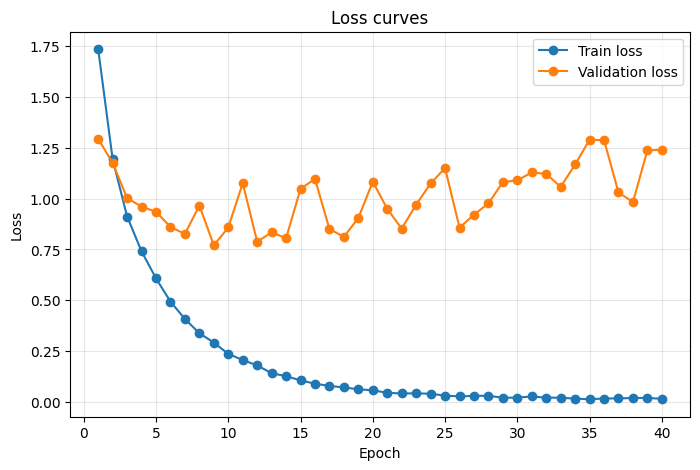

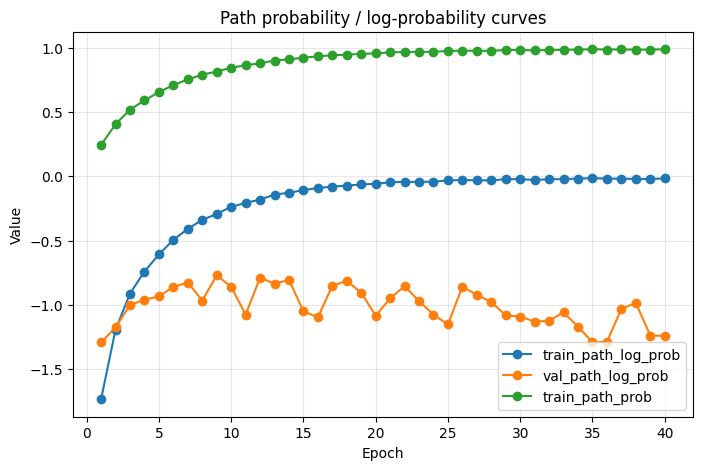

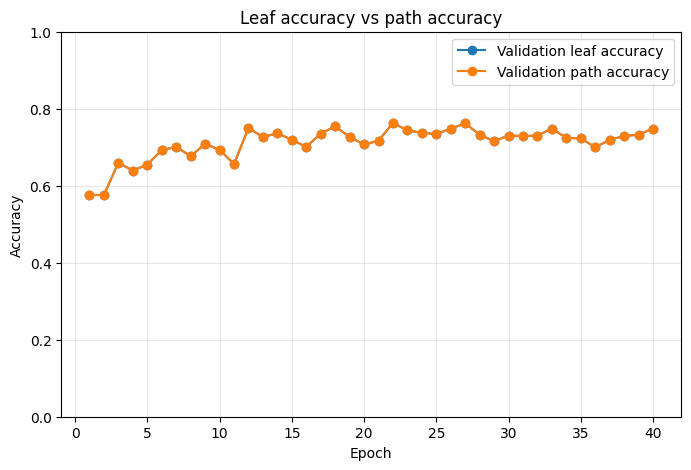

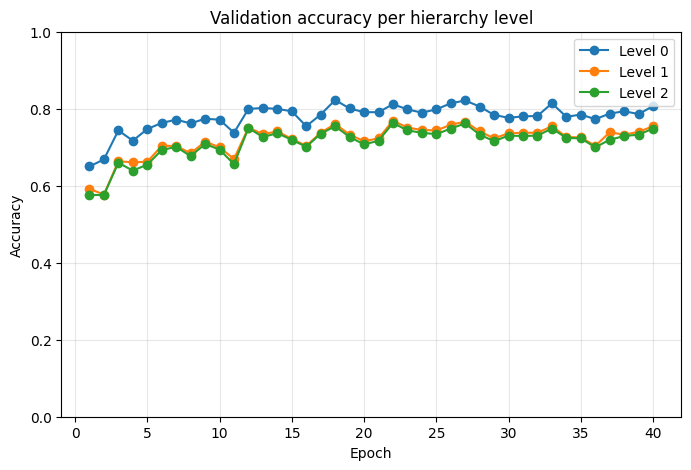

In [10]:
plot_training_dynamics(exp.metrics)

best epoch: 9


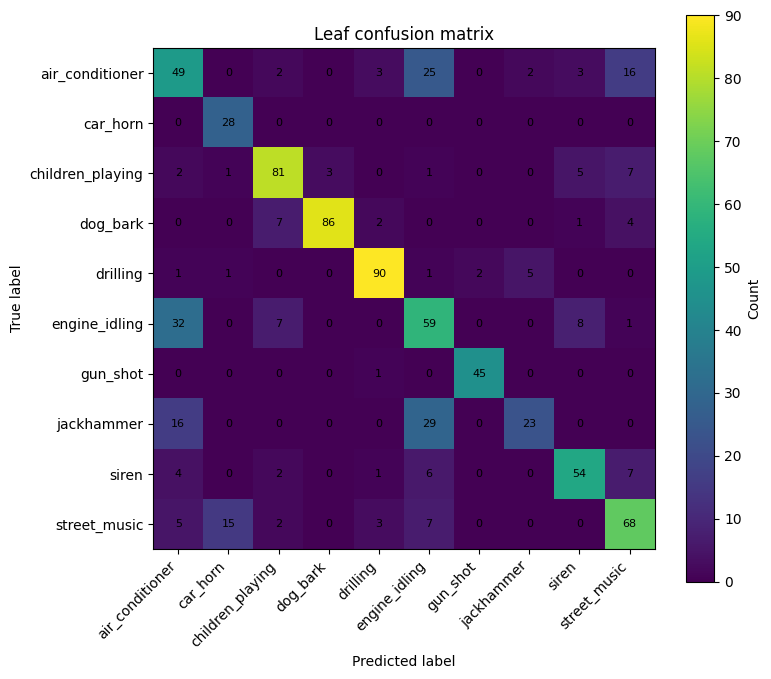


Leaf confusion matrix metrics
-----------------------------
Accuracy:          0.7084
Macro precision:   0.7346
Macro recall:      0.7338
Macro specificity: 0.9671
Macro F1-score:    0.7206


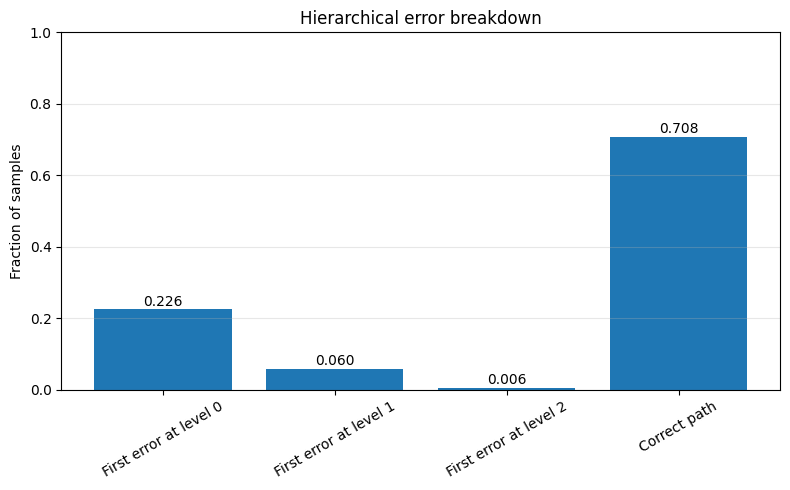

,category,count,fraction
1,0.0,186,0.226002
2,1.0,49,0.059538
3,2.0,5,0.006075
0,correct_path,583,0.708384


In [11]:
best_epoch = exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)

plot_leaf_confusion_matrix(epoch_preds, index_dict=hierarchy_index_dict)
plot_hierarchical_error_breakdown(epoch_preds)

best epoch: 31
Conditioned on correctly predicted level 0: vehicle (150 samples)


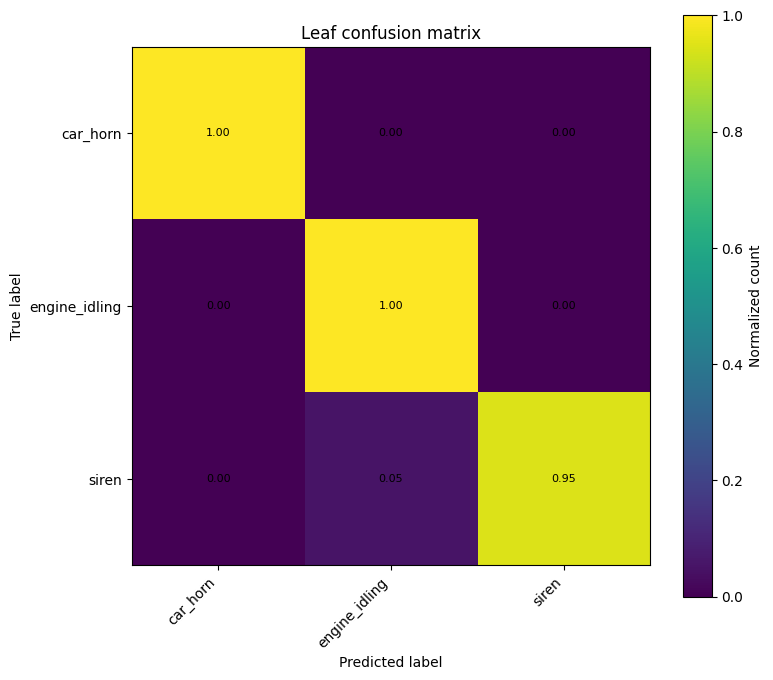


Leaf confusion matrix metrics
-----------------------------
Accuracy:          0.9800
Macro precision:   0.9844
Macro recall:      0.9828
Macro specificity: 0.9888
Macro F1-score:    0.9832


(array([[31,  0,  0],
        [ 0, 61,  0],
        [ 0,  3, 55]]),
 [1, 5, 8],
 {'accuracy': np.float64(0.98),
  'macro_precision': np.float64(0.984375),
  'macro_recall': np.float64(0.9827586206896551),
  'macro_specificity': np.float64(0.9887640449438203),
  'macro_f1': np.float64(0.9831504424778762),
  'per_class':    class_index  tp  fp  fn   tn  precision    recall  specificity        f1
  0            0  31   0   0  119   1.000000  1.000000     1.000000  1.000000
  1            1  61   3   0   86   0.953125  1.000000     0.966292  0.976000
  2            2  55   0   3   92   1.000000  0.948276     1.000000  0.973451})

In [6]:
best_epoch = exp.best_epoch("val_leaf_acc")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)

plot_leaf_confusion_given_correct_level(
    epoch_preds,
    level=0,
    class_id=1,   # e.g. construction
    index_dict=hierarchy_index_dict,
    normalize=True
)


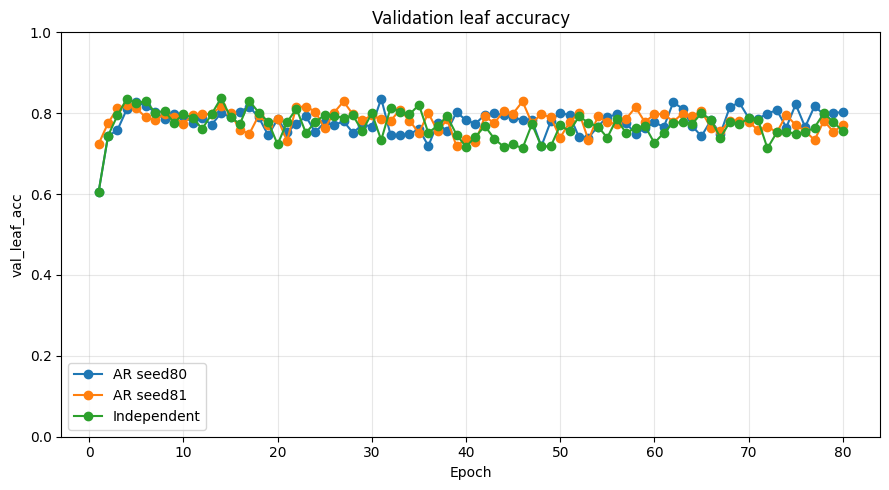

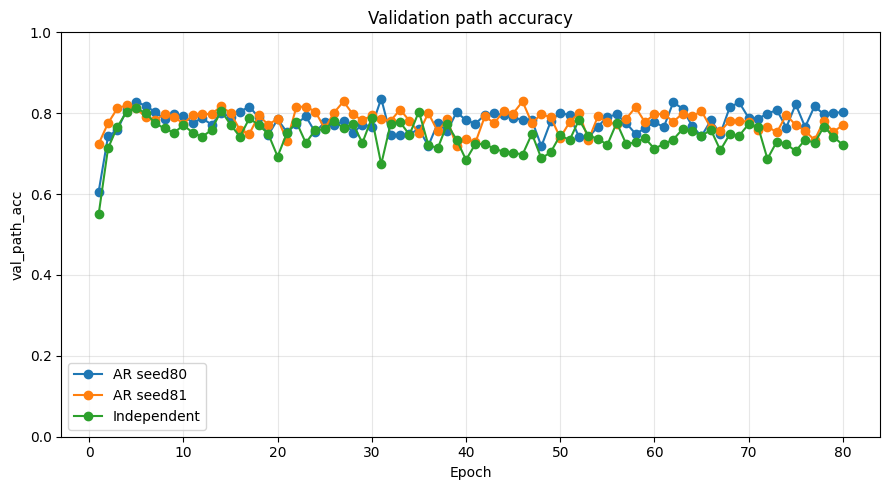

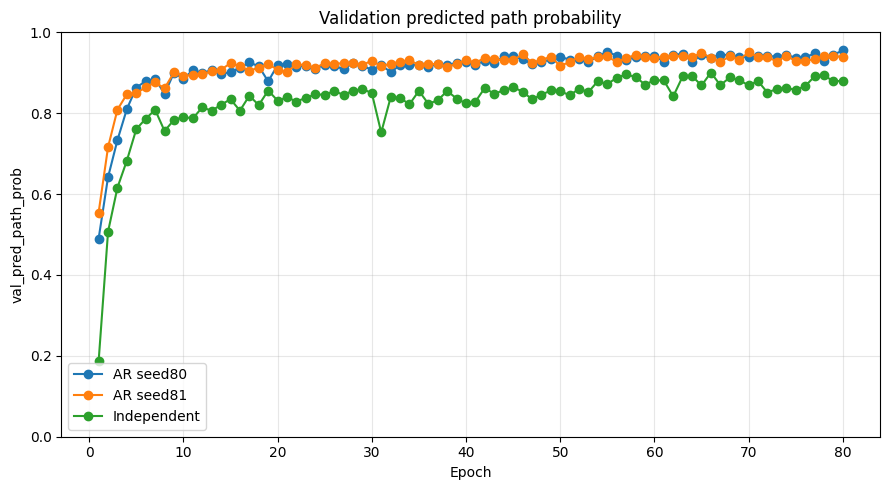

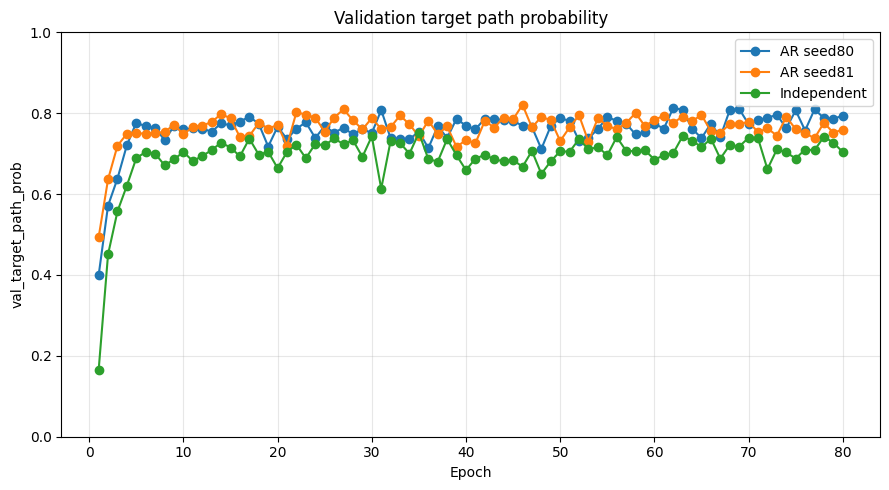

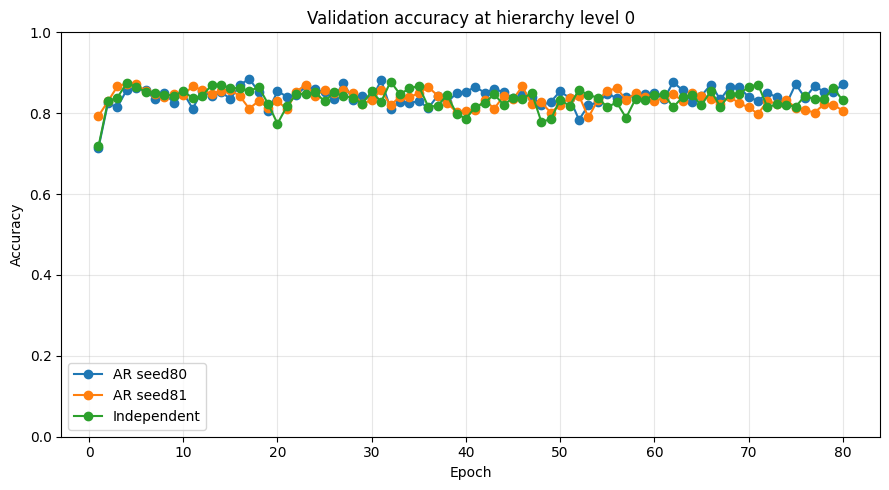

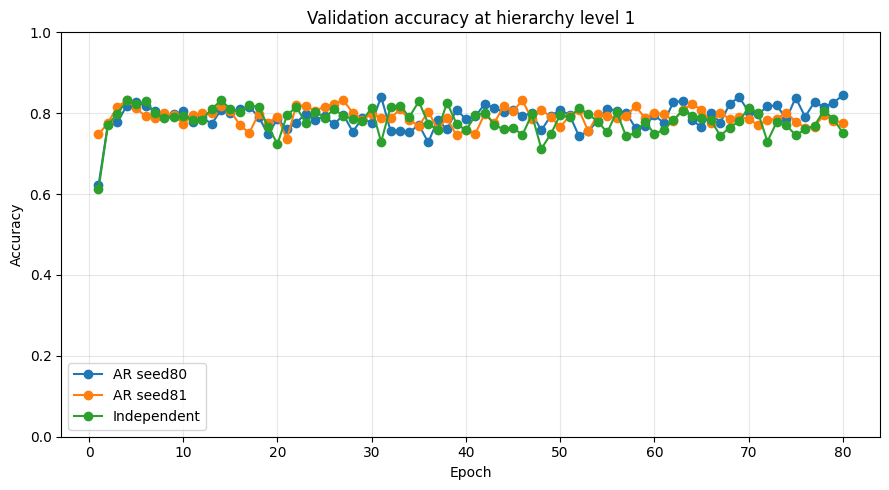

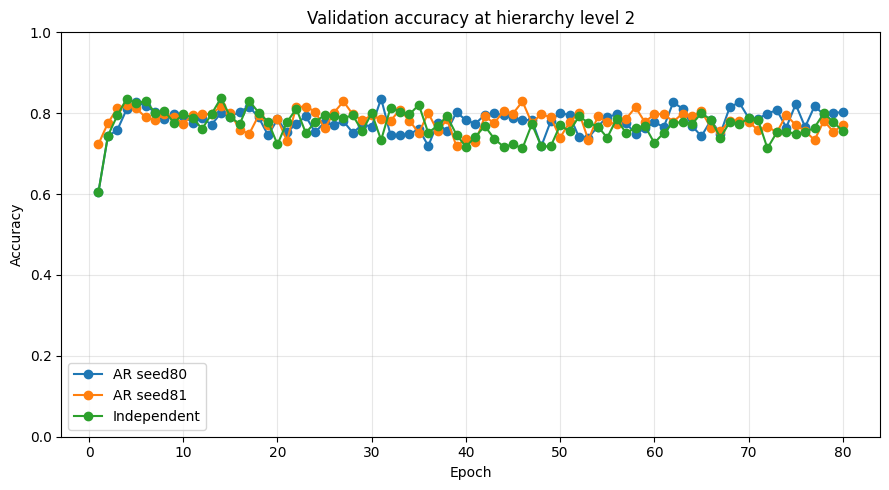

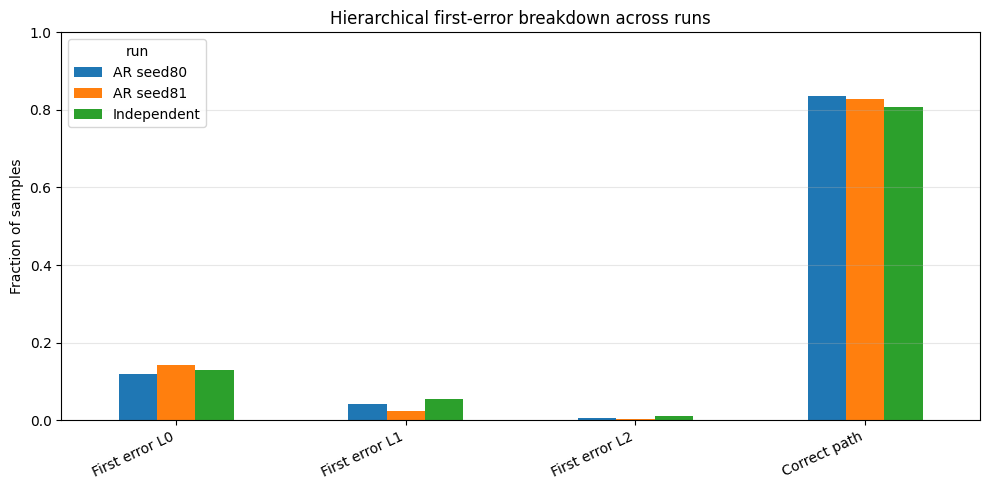

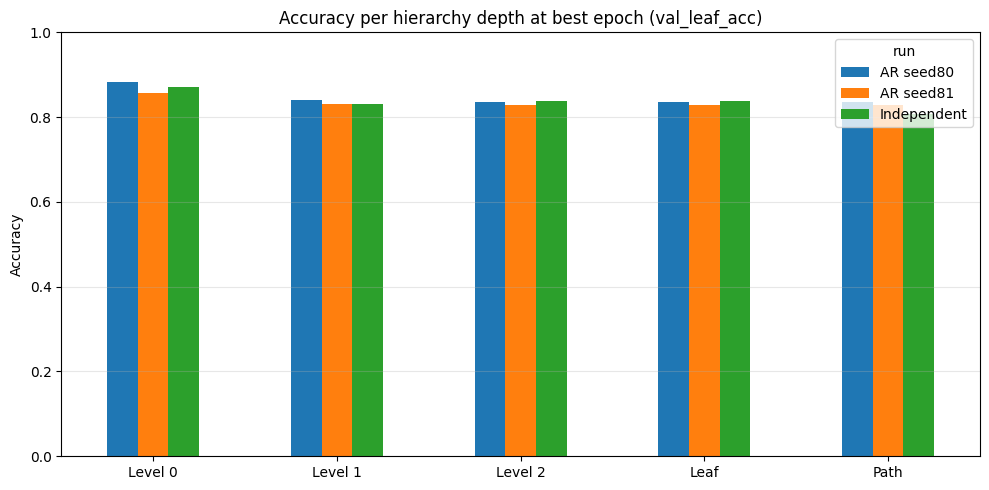

,run,epoch,depth,accuracy
0,AR seed80,31,Level 0,0.881720
1,AR seed80,31,Level 1,0.841099
2,AR seed80,31,Level 2,0.836320
3,AR seed80,31,Leaf,0.836320
4,AR seed80,31,Path,0.836320
5,AR seed81,27,Level 0,0.856631
6,AR seed81,27,Level 1,0.831541
7,AR seed81,27,Level 2,0.829152
8,AR seed81,27,Leaf,0.829152
9,AR seed81,27,Path,0.829152


In [12]:
experiments = load_many_experiments(
    [
        "outputs/ar_hierarchy_masked_seed80",
        "outputs/ar_hierarchy_masked_seed81",
        "outputs/independent_hierarchy_seed80",
    ],
    names=["AR seed80", "AR seed81", "Independent"],
    epoch_range=[0, 80]
)

plot_compare_core_curves(experiments)
summarize_best_epochs(experiments)
compare_hierarchical_error_breakdowns(experiments)
plot_compare_accuracy_per_depth_at_best_epoch(experiments)

### Old

In [7]:
import utils.inspect_data_helpers_old as old_helpers

exp_dir = "outputs/ar_hierarchy_masked_seed80"
config_path = exp_dir+"/config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)


hiearchy_tree = get_hierarchy_tree(config["dataset"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()
metrics, preds = old_helpers.load_experiment(exp_dir)

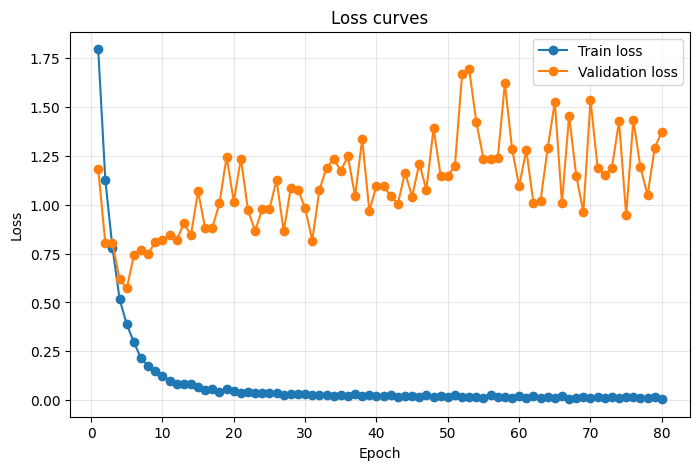

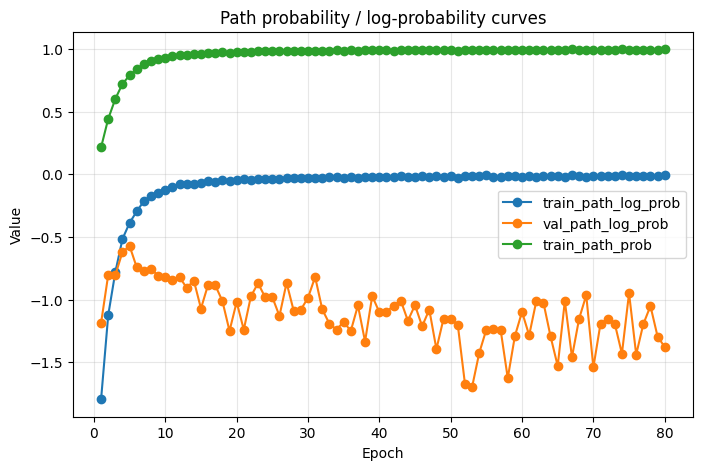

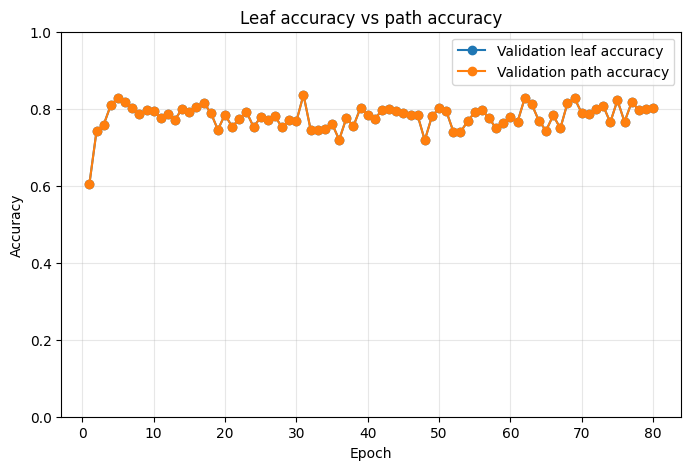

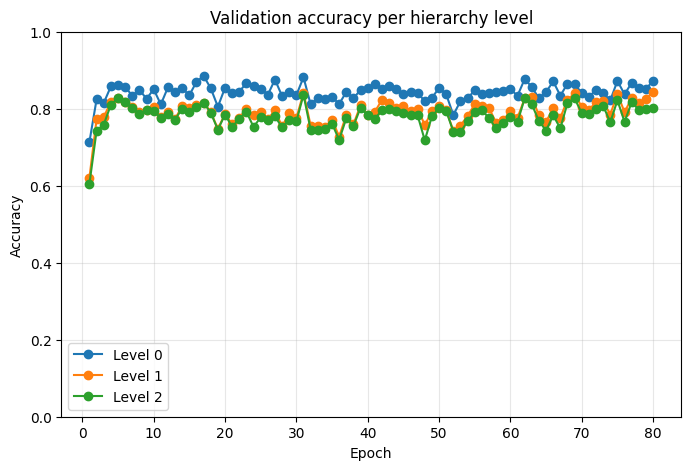

In [8]:
old_helpers.plot_training_dynamics(metrics)

best epoch: 31


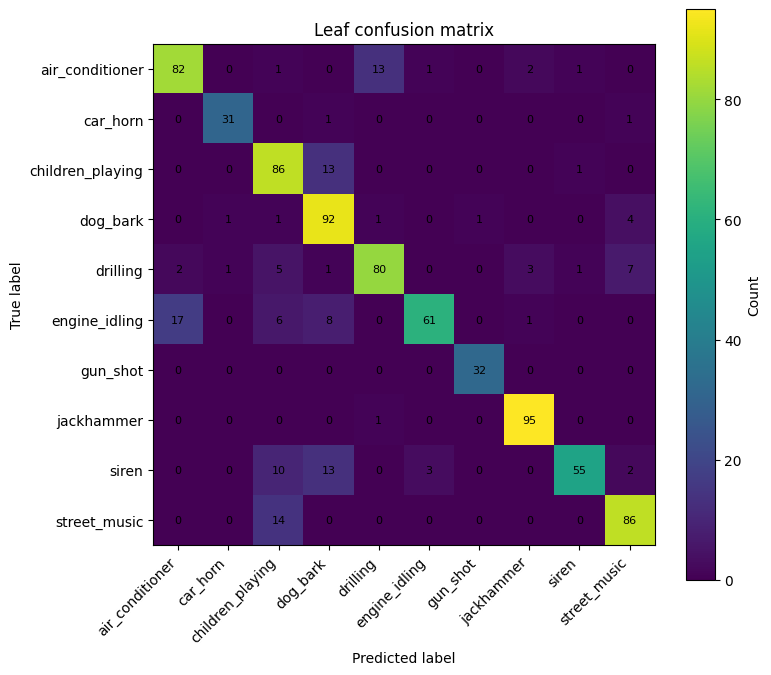


Leaf confusion matrix metrics
-----------------------------
Accuracy:          0.8363
Macro precision:   0.8668
Macro recall:      0.8508
Macro specificity: 0.9815
Macro F1-score:    0.8516


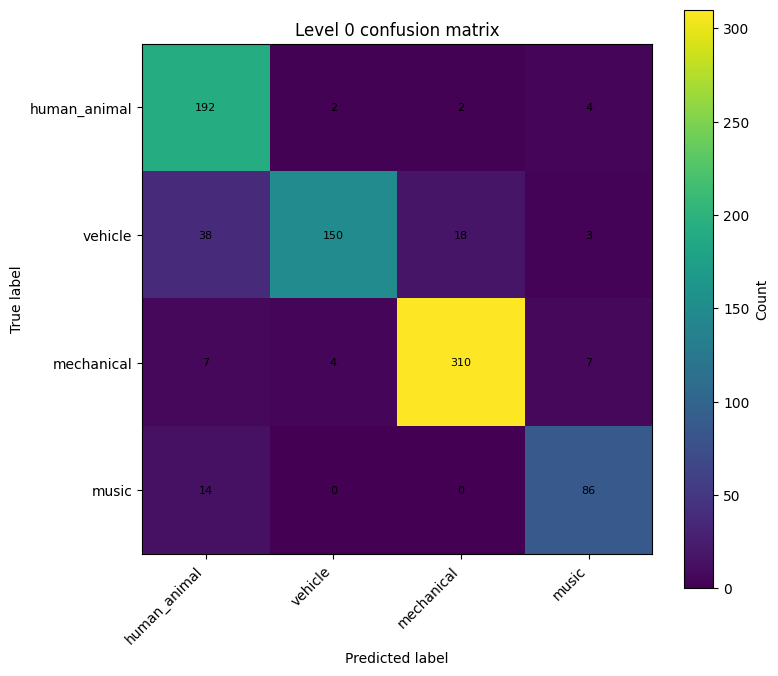


Level 0 confusion matrix metrics
--------------------------------
Accuracy:          0.8817
Macro precision:   0.8815
Macro recall:      0.8707
Macro specificity: 0.9599
Macro F1-score:    0.8689


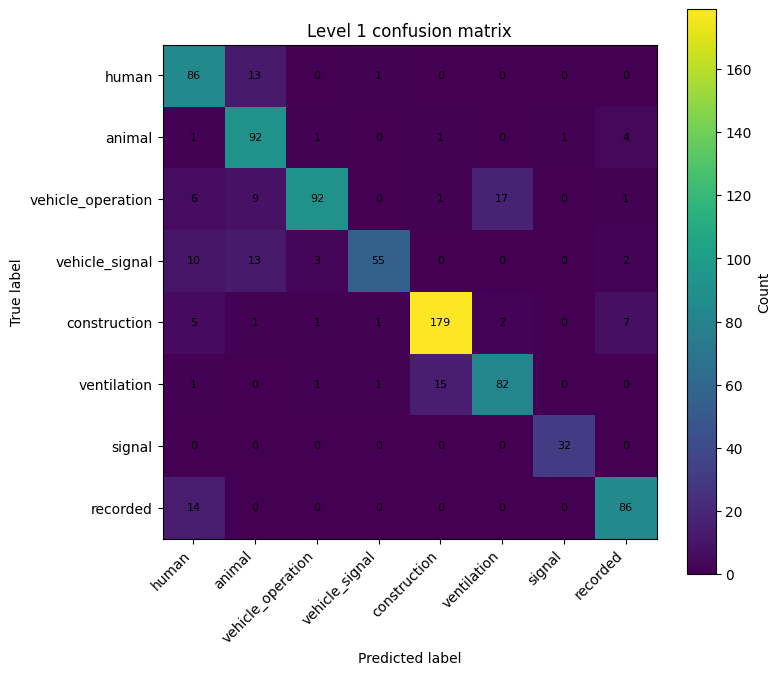


Level 1 confusion matrix metrics
--------------------------------
Accuracy:          0.8411
Macro precision:   0.8575
Macro recall:      0.8458
Macro specificity: 0.9770
Macro F1-score:    0.8442


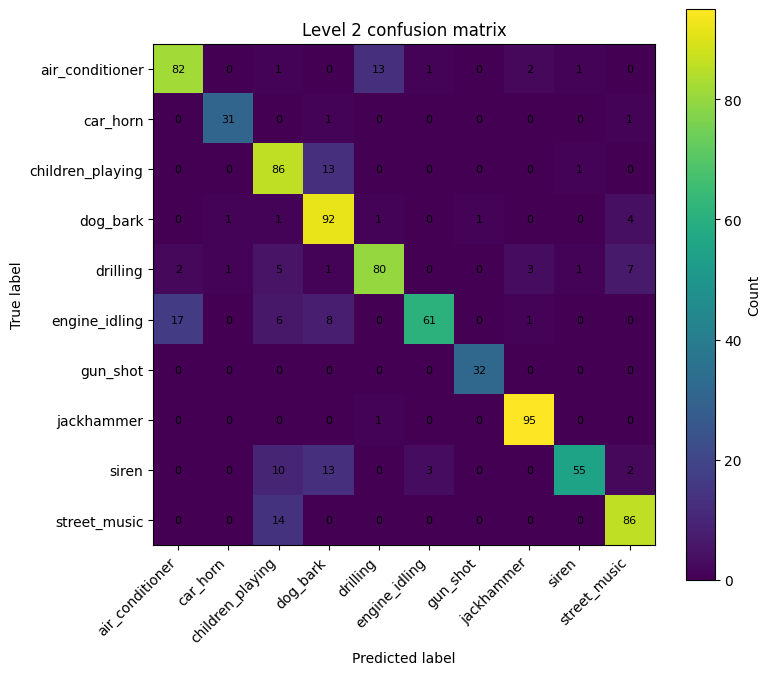


Level 2 confusion matrix metrics
--------------------------------
Accuracy:          0.8363
Macro precision:   0.8668
Macro recall:      0.8508
Macro specificity: 0.9815
Macro F1-score:    0.8516


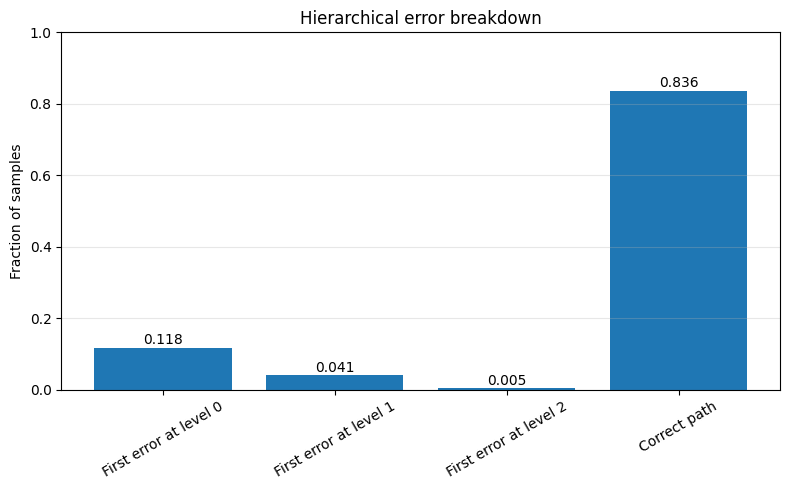

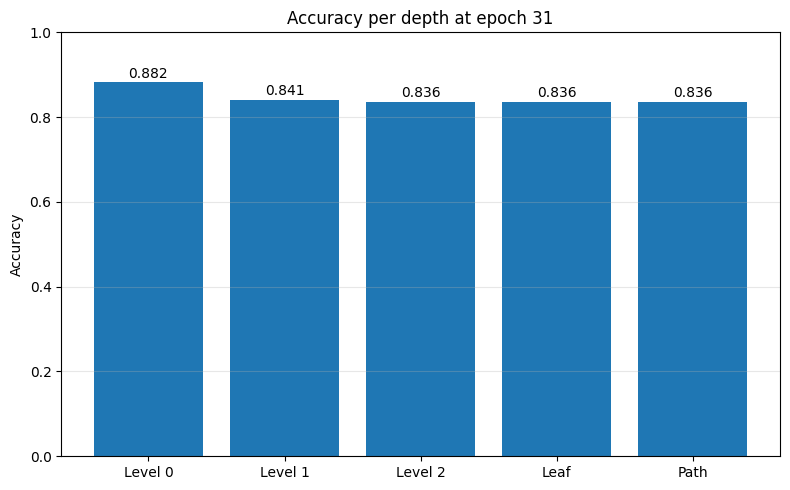

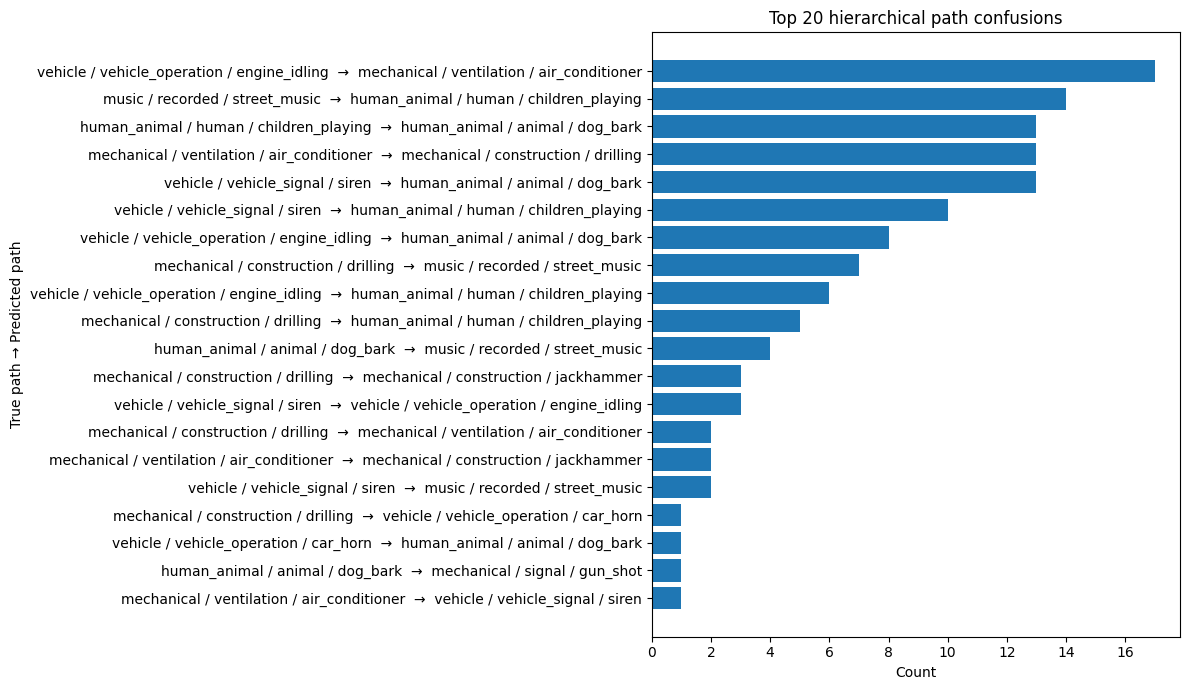

,true_path,pred_path,count
10,vehicle / vehicle_operation / engine_idling,mechanical / ventilation / air_conditioner,17
11,music / recorded / street_music,human_animal / human / children_playing,14
12,human_animal / human / children_playing,human_animal / animal / dog_bark,13
13,mechanical / ventilation / air_conditioner,mechanical / construction / drilling,13
14,vehicle / vehicle_signal / siren,human_animal / animal / dog_bark,13
15,vehicle / vehicle_signal / siren,human_animal / human / children_playing,10
16,vehicle / vehicle_operation / engine_idling,human_animal / animal / dog_bark,8
17,mechanical / construction / drilling,music / recorded / street_music,7
18,vehicle / vehicle_operation / engine_idling,human_animal / human / children_playing,6
19,mechanical / construction / drilling,human_animal / human / children_playing,5


In [9]:
best_epoch = old_helpers.choose_best_epoch(metrics, metric="val_leaf_acc")
print(f"best epoch: {best_epoch}")
epoch_preds = old_helpers.filter_predictions_by_epoch(preds, best_epoch)

old_helpers.plot_leaf_confusion_matrix(epoch_preds, index_dict=hierarchy_index_dict)
old_helpers.plot_all_level_confusion_matrices(epoch_preds, index_dict=hierarchy_index_dict)

old_helpers.plot_hierarchical_error_breakdown(epoch_preds)
old_helpers.plot_accuracy_per_depth(metrics=metrics, epoch=best_epoch)
old_helpers.plot_top_hierarchical_confusions(epoch_preds, index_dict=hierarchy_index_dict)